<a href="https://colab.research.google.com/github/yashita-mishra/IML-Assignment-2/blob/main/A2Q2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
import pandas as pd

In [2]:
def kmeans(X, K, max_iter=300, tol=1e-4, random_state=42):
    rng = np.random.default_rng(random_state)
    N, d = X.shape
    centers = np.empty((K, d))
    centers[0] = X[rng.integers(0, N)]
    for k in range(1, K):
        dists = np.min(((X[:, None, :] - centers[:k][None, :, :]) ** 2).sum(-1), axis=1)
        probs = dists / dists.sum()
        centers[k] = X[rng.choice(N, p=probs)]

    for it in range(max_iter):
        d2 = ((X[:, None, :] - centers[None, :, :]) ** 2).sum(-1)
        labels = np.argmin(d2, axis=1)
        new_centers = np.array([
            X[labels == k].mean(axis=0) if (labels == k).any() else centers[k]
            for k in range(K)
        ])
        if np.linalg.norm(new_centers - centers) < tol:
            break
        centers = new_centers

    inertia = ((X - centers[labels]) ** 2).sum()
    return labels, centers, inertia

In [5]:
from sklearn.datasets import load_iris

iris = load_iris()
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df['target'] = iris.target
display(iris_df.head())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [7]:
X = iris.data
yr = iris.target
feats = iris.feature_names
print(f"X={X.shape}, features={feats}")
Xs = (X - X.mean(0)) / (X.std(0) + 1e-12)
Xc = Xs - Xs.mean(0)
U,s,Vt = np.linalg.svd(Xc, full_matrices=False)
X2d = Xc @ Vt[:2].T
Ks = [2,3,4,5]
results = {}
for k in Ks :
  km = kmeans(X=X2d, K = k, max_iter=300, tol=1e-4, random_state=42)
  results[k] = km
  print(f"k={k}: loss={km[2]:.4f}")

X=(150, 4), features=['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
k=2: loss=197.4038
k=3: loss=116.0177
k=4: loss=90.0972
k=5: loss=66.5953


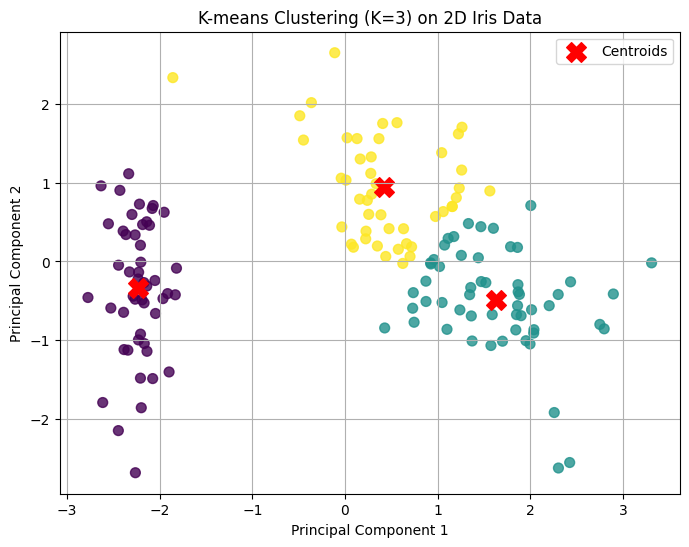

In [8]:
K_to_plot = 3
labels_k3, centers_k3, inertia_k3 = results[K_to_plot]

plt.figure(figsize=(8, 6))
plt.scatter(X2d[:, 0], X2d[:, 1], c=labels_k3, cmap='viridis', s=50, alpha=0.8)
plt.scatter(centers_k3[:, 0], centers_k3[:, 1], c='red', marker='X', s=200, label='Centroids')
plt.title(f'K-means Clustering (K={K_to_plot}) on 2D Iris Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

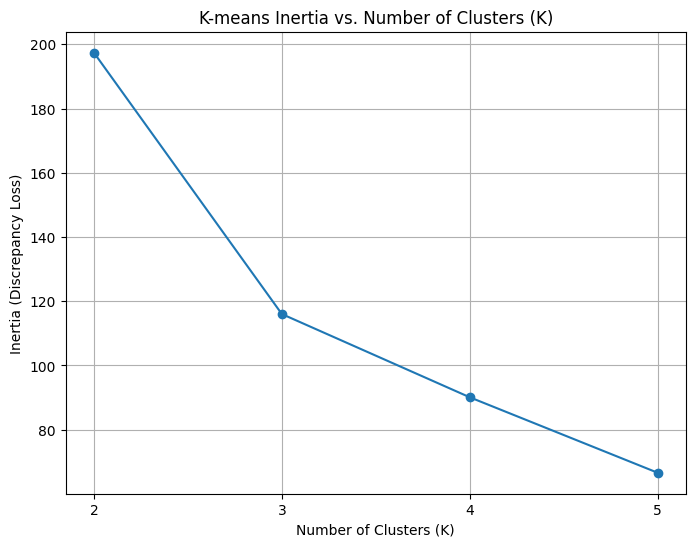

In [9]:
k_values = list(results.keys())
inertia_values = [results[k][2] for k in k_values]

plt.figure(figsize=(8, 6))
plt.plot(k_values, inertia_values, marker='o', linestyle='-')
plt.title('K-means Inertia vs. Number of Clusters (K)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Discrepancy Loss)')
plt.xticks(k_values)
plt.grid(True)
plt.show()